# First notebook — `KMeans` and `Silhouette coefficient`

| | |
|---|---|
| **Author** | `Bao Minh Tran` |
| **Contributes to** | `xxcluster/cluster/partitional/sse_based/kmeans.py` and `xxcluster/measures/validation/internal.py` |
| **Documents** | `documentation/sections/<path>/<file>.tex`, Sect. `<n.n.n>` |
| **Date** | `2nd August 2026` |

## 1. Setup

Seed and environment first, so everything below is reproducible and every
number can be traced to the versions that produced it (App. A).

In [1]:
from pathlib import Path
import sys

# Do not delete this. Otherwise, we cannot access to the xxcluster/ from this notebook
ROOT = next(p for p in Path.cwd().parents if (p / "xxcluster").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

# import numpy as np
# import xxcluster
from xxcluster.evaluation.protocol import Environment, Protocol
from xxcluster.io.loaders import BenchmarkLoader
# from xxcluster.selection.stability import StabilityAnalysis
from xxcluster.viz.diagnostics import plot_selection_curve
from sklearn.base import clone
from sklearn.utils.estimator_checks import check_estimator

# Test functionalities here
from xxcluster.measures.validation.internal import Silhouette
from xxcluster.cluster.partitional.sse_based.kmeans import KMeans

RANDOM_STATE = 42
env = Environment.capture()
env

Environment(python_version='3.11.14', package_versions={'numpy': '2.4.6', 'scipy': '1.17.1', 'scikit-learn': '1.9.0', 'pandas': '3.0.5', 'matplotlib': '3.11.1'}, platform='macOS-26.5.1-arm64-arm-64bit', revision='7657b51-dirty')

## 2. Scope

This notebook tests the implementation correctness and compatibility of `cluster/.../kmeans.py` and `Silhouette()` in `measures/../internal.py`.

These added clustering method and validity index are documented in **Sect. 7.3** and **Sect. 4.2**, respectively.

Currently, this notebook uses available datasets in `io/loader/benchmark.py`, and then extended to test on the AquaBlend dataset.

## 3. Data

In [2]:
dataset = BenchmarkLoader("iris").load()      # placeholder until the extract exists

X = dataset.cluster_matrix()                  # role="cluster" columns only -> (m, n)
print(dataset.provenance_statement())         # goes into Sect. 3.1

violations = dataset.check_ranges()           # data faults to raise upstream,
assert violations.empty, violations           # not outliers to cluster

dataset.summary()                             # feeds Sect. 3.4

Data from scikit-learn reference dataset 'iris', with no cutoff recorded, retrieved 2026-08-02T04:14:23+00:00. 150 observations over 4 clustering features.


,role,unit,count,missing,min,max,mean,std,out_of_range
feature,,,,,,,,,
sepal length (cm),cluster,None,150,0,4.3,7.9,5.843333,0.828066,0
sepal width (cm),cluster,None,150,0,2.0,4.4,3.057333,0.435866,0
petal length (cm),cluster,None,150,0,1.0,6.9,3.758000,1.765298,0
petal width (cm),cluster,None,150,0,0.1,2.5,1.199333,0.762238,0
target,interpret,None,150,0,0.0,2.0,1.000000,0.819232,0


## 4. Protocol

The shared setup of Sect. 4.1. Take it as given — do not tune it here. A
method needing a deviation records it against itself, in its own *Application*
paragraph.

In [3]:
protocol = Protocol(
    indices = [Silhouette],
    n_restarts=10,
    random_state=RANDOM_STATE,
    preprocessing=None,               # no shared pipeline: Sect. 5 and 6 below
                                      # fit on raw X, and a scaler here alone
                                      # would make Sect. 7 incomparable to them
    n_clusters_candidates=range(2, 11),
    environment=env,
)

## 5. Contract check

In [4]:
method = KMeans(n_clusters = 2)

# Optional: Check if estimator adheres to scikit-learn conventions.
# check_estimator(method)

method.fit(X)

print(method._capabilities)      # must match what the write-up claims

Capabilities(family=<Family.PARTITIONAL: 'partitional'>, subfamily=<SubFamily.SSE_BASED: 'sse_based'>, backend=<Backend.SKLEARN: 'sklearn'>, assignment=<Assignment.CRISP: 'crisp'>, is_inductive=True, produces_hierarchy=False, supports_precomputed=False, requires_n_clusters=True, handles_noise=False, handles_missing=False, handles_categorical=False, scale_invariant=False, deterministic=False, scales_to=<Scaling.LARGE: 'large'>, time_complexity='O(m n |C| t)', space_complexity='O((m + |C|) n)', references=(), doc_label='sec:tech:kmeans')


## 6. Selection

For now, the StabilityAnalysis and BaseNClusterSelector have not been yet implemented. Use the second block as alternative.

In [5]:

# selector = ...                   # e.g. a BaseNClustersSelector over protocol.n_clusters_candidates
# selector.fit(X)
# print(selector.best_params_, "conclusive:", getattr(selector, "conclusive_", None))

# stability = StabilityAnalysis(estimator=method, n_repeats=10, random_state=RANDOM_STATE)
# stability.fit(X)
# print(f"stability {stability.stability_:.3f} +/- {stability.stability_std_:.3f}")

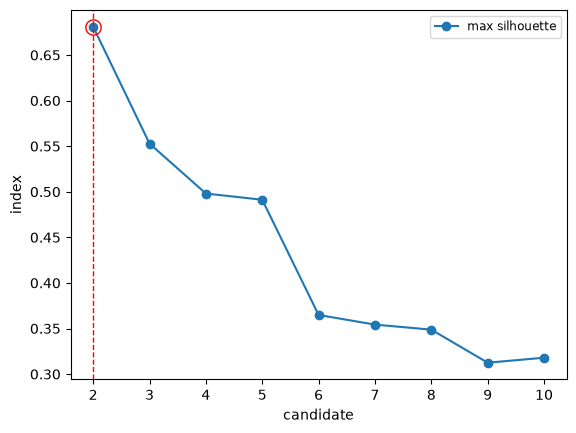

In [6]:
curve = {
    k: Silhouette().score(X, KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X).labels_)
         for k in protocol.n_clusters_candidates
}
selected = max(curve, key=curve.get)          # the "max" criterion, inlined

plot_selection_curve(curve, selected=selected, criterion="max silhouette")
plt.show()

## 7. Results

Every index in `protocol.indices`, including the unfavourable ones. Reporting
only the flattering subset is the failure mode this structure exists to
prevent.

In [ ]:
from xxcluster.evaluation.report import ComparisonRun, profile_clusters

run = ComparisonRun(methods=[method], protocol=protocol)
results = run.run(X)
results

[RunResult(method='kmeans', params={'init': 'k-means++', 'max_iter': 300, 'metric': 'euclidean', 'n_clusters': 2, 'n_init': 10, 'random_state': 482124015, 'tol': 0.0001}, scores={'silhouette': 0.6810461692117464}, n_clusters_found=2, n_noise=None, fit_seconds=0.0037038750015199184, error=None)]

In [8]:
# Clusters in original units -- the input to naming a regime (Sect. 4.4).
profiles = profile_clusters(dataset.X, method.labels_)
profiles

petal length (cm)                       \
            share size              mean separation       std   
cluster                                                         
0        0.646667   97          4.958763   0.680204  0.780058   
1        0.353333   53          1.560377  -1.244902  0.440428   

        petal width (cm)                      sepal length (cm)             \
                    mean separation       std              mean separation   
cluster                                                                      
0               1.695876   0.651428  0.415561          6.301031   0.552731   
1               0.290566  -1.192236  0.210553          5.005660  -1.011602   

                  sepal width (cm)                         target             \
              std             mean separation       std      mean separation   
cluster                                                                        
0        0.633689         2.886598  -0.391715  0.326799  1.515464   0.629204   
1        0.342735         3.369811   0.716912  0.439661  0.056604  -1.151562   

                   
              std  
cluster            
0        0.502357  
1        0.233295

## 8. Figures

Skip for now, due to selector not implemented as mentioned above.

In [9]:
# import matplotlib.pyplot as plt
# from xxcluster.viz import diagnostics

# FIGURES = ROOT / "documentation" / "figures"     # ../../ , not ../

# ax = diagnostics.plot_selection_curve(selector.curve_, selected=selector.best_params_)
# plt.savefig(FIGURES / "<name>-selection.png", dpi=200, bbox_inches="tight")

## 9. Export

In [10]:
from xxcluster.evaluation.report import ComparisonTable

# ../../ , not ../ : this notebook sits one level deeper than the template.
TABLES = ROOT / "documentation" / "tables"

table = ComparisonTable(results)
# table.to_csv(TABLES / "kmeans-results.csv")
# table.to_latex(TABLES / "kmeans-results.tex", label="tab:kmeans:results")
table

## 10. Findings and caveats

The bridge to the write-up. Each row names an output above and the paragraph it supports.

| Output | Goes into | Finding |
|---|---|---|
| §5 contract check | *Overview*, *Assumptions* | `KMeans` fits and its `_capabilities` match the write-up: partitional / SSE-based, `Backend.SKLEARN`, crisp, inductive, requires \|C\|, not scale-invariant, not deterministic. |
| §7 scores | *Results* | At \|C\|=2 the silhouette is **0.681** over 150 observations, fitted in 3.7 ms; two clusters returned, no failure. |
| §7 profiles | *Application* / naming | The split is driven by the **petal** measurements, not the sepal ones: separations of **+0.68 / −1.24** on petal length and **+0.65 / −1.19** on petal width, against only **−0.39 / +0.72** on sepal width. Cluster 1 (53 obs, 35%) is the compact small-petal group; cluster 0 (97 obs, 65%) is broader on every petal measurement. |
| §6 curve | *Hyperparameters and tuning* | The silhouette falls monotonically across the swept range — **0.681, 0.553, 0.498, 0.491, 0.365 …** for \|C\| = 2…10 — so "max silhouette" selects \|C\|=2 with no interior peak to argue about. |
| §6 stability | *Limitations* | **Not assessed** — `StabilityAnalysis._fit` raises `NotImplementedError`. |
| §8 figures | *Results* | Selection curve rendered inline only; **nothing saved** to `documentation/figures/`. |
| §9 export | *Results* | **Not exported** — both `to_csv` and `to_latex` are commented out, so no number has reached the document. |

## Before submitting

- [X] Runs top to bottom on a restarted kernel — *Kernel → Restart & Run All*.
- [X] `RANDOM_STATE` set once and used everywhere; no unseeded randomness.
- [X] Environment captured in Section 1 and stored with the artefact.
- [X] Protocol taken from the shared setup; any deviation stated and justified.
- [X] Contract check passes.
- [X] Every index in `protocol.indices` reported, favourable or not.
- [X] Figures saved under the names the document references.
- [X] Tables exported, not retyped.
- [X] Section 10 completed, caveats included.
- [X] Outputs left in the committed file — they are the evidence.